In [1]:
%load_ext autoreload
%autoreload 2
from scripts.utils import *
from scripts.gaussianclassifiers import *
from scripts.dcf import *
from scripts.plots import *

# Analysis and Evaluation of MVG Models for Different Target Applications

The objective of this project phase is to analyze and compare the performance of the Gaussian classifiers (MVG, Tied, and Naive Bayes) using the Detection Cost Function (DCF) utilities implemented in [dcf.py](../scripts/dcf.py). The evaluation will not be limited to the simple absolute error count, but will take into account the economic or operational impact of the decisions made by computing the expected Bayes risk for different application scenarios.

## Application Parameterization and Decision Thresholds

In a binary classification problem, each target application is uniquely defined by a triplet of parameters denoted by $(\pi_{1}, C_{fn}, C_{fp})$. By modifying the weights within the application, the system's behavior changes drastically: for example, an increase in the false positive cost $C_{fp}$ will shift the threshold, inducing the recognizer to be more conservative to guarantee stricter security requirements.

## Representation via Effective Prior

To simplify the analytical comparison between different systems, the misclassification costs can be mathematically incorporated into the prior probabilities. Any application defined by the triplet $(\pi_{1}, C_{fn}, C_{fp})$ is operationally equivalent to a normalized application where the costs are assumed unitary, formally defined as $(\tilde{\pi}, 1, 1)$. The term $\tilde{\pi}$ is called the **effective prior**.

## Empirical Risk and Minimum DCF

The quantitative evaluation of the discriminative power of the models is based on the extraction of the normalized Detection Cost Function (DCF), which expresses the empirical risk actually taken by the classifier operating on the evaluation data. To isolate the intrinsic effectiveness of the model from calibration errors, the analysis requires the computation of the **Minimum DCF**. The gap between the actual DCF and the Minimum DCF quantifies the performance loss attributable exclusively to the mis-calibration of the scores.

## Global Analysis via Bayes Error Plots

In order to obtain a complete overview of the recognizers' behavior under extreme application uncertainty, we use Bayes Error Plots. In this analytical space, the normalized cost functions (both the actual DCF and the minimum DCF) are plotted as a function of the prior log-odds, extending the analysis over a continuous domain that embraces a wide variety of possible scenarios.

### 📘 Theory & Key Functions
**Theoretical Recall:** Bayes decision theory minimizes the expected risk of decisions. The optimal decision boundary depends on the prior probabilities ($\pi$) and misclassification costs ($C_{fn}$, $C_{fp}$). 
- **Actual DCF (Detection Cost Function)** measures the empirical risk of a model at a specific application threshold.
- **Minimum DCF** is the lowest possible DCF achievable by the model if the threshold were perfectly oracle-tuned. The gap between them indicates *mis-calibration*.

**Key Functions (from `dcf.py`):**
- `DCF_norm()`: Computes the normalized empirical risk (actual DCF) given the system's scores and the application parameters.
- `compute_min_dcf()`: Sorts all scores and tests them as possible thresholds to find the theoretical minimum DCF.
- `plot_bayes_error()`: Generates a plot of DCF versus prior log-odds, allowing us to evaluate the model's robustness across a wide range of operating scenarios.

In [2]:
D,L,labels=init_dataset()


Let's make predictions using the MVG Classifier.

In [3]:
(DTR, LTR), (DVAL, LVAL)=split_db_2to1(D,L)
predictions=MVG_Classifier(DTR,LTR,DVAL,LVAL)
predictions

The error rate for Binary Classifier based on MVG is: 6.999999999999995% and the accuracy: 93.0%


array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [4]:
M=get_confusion_mat(predictions,LVAL)
M

array([[927.,  75.],
       [ 65., 933.]])

In [5]:
# 5 applicazioni con parametri diversi (π1, Cfn, Cfp)
applications = [
    (0.5, 1.0, 1.0),   # prior uniforme e costi uniformi
    (0.9, 1.0, 1.0),   # prior più alto per campioni genuini
    (0.1, 1.0, 1.0),   # prior più alto per campioni falsi
    (0.5, 1.0, 9.0),   # prior uniforme, costo alto per falsi positivi (focalizzato sulla sicurezza)
    (0.5, 9.0, 1.0)    # prior uniforme, costo alto per falsi negativi (focalizzato sulla facilità d'uso)
]

dcf_results = []
for prior, cfn, cfp in applications:
    # Calcolo del prior effettivo
    eff_prior = (prior * cfn) / (prior * cfn + (1 - prior) * cfp)
    dcf_u_value=DCF_u(predictions,LVAL,prior,cfn,cfp)
    dcf_norm_value = DCF_norm(predictions, LVAL, prior, cfn, cfp)
    dcf_results.append(dcf_norm_value)
    print(f"Applicazione (π1={prior}, Cfn={cfn}, Cfp={cfp}) -> π effettivo = {eff_prior:.1f}")
    print(f"  DCF_u = {dcf_u_value:.4f} || DCF_norm = {dcf_norm_value:.4f}\n")



Applicazione (π1=0.5, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.5
  DCF_u = 0.0700 || DCF_norm = 0.1399

Applicazione (π1=0.9, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.9
  DCF_u = 0.0735 || DCF_norm = 0.7352

Applicazione (π1=0.1, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.1
  DCF_u = 0.0664 || DCF_norm = 0.6641

Applicazione (π1=0.5, Cfn=1.0, Cfp=9.0) -> π effettivo = 0.1
  DCF_u = 0.3321 || DCF_norm = 0.6641

Applicazione (π1=0.5, Cfn=9.0, Cfp=1.0) -> π effettivo = 0.9
  DCF_u = 0.3676 || DCF_norm = 0.7352



Now let's compute the various LLRs to feed into the Bayesian decision functions.

In [6]:
#Calcoliamo tutti gli llr
S_MVG=getS(DVAL,get_params_MVG(DTR,LTR))
S_TiedC=getS_Tied_Covariance(DVAL,get_params_Tied_Covariance(DTR,LTR))
S_Naive=getS(DVAL,get_params_Naive_Bayes(DTR,LTR))

llr_MVG=S_MVG[1]-S_MVG[0]
llr_TiedC=S_TiedC[1]-S_TiedC[0]
llr_Naive=S_Naive[1]-S_Naive[0]

models={
    "MVG Classifier":llr_MVG,
    "Tied Covariance Classifier":llr_TiedC,
    "Naive Bayes Classifier":llr_Naive,
}

effective_priors = [0.1, 0.5, 0.9]

for model_name,model_llr in models.items():
    print(f"--- Valutazione Modello: {model_name} ---")

    for pi_eff in effective_priors:
        predictions=get_bayes_decision(model_llr,pi_eff,1,1)
        actual_dcf=DCF_norm(predictions,LVAL,pi_eff,1,1)
        min_dcf=compute_min_dcf(model_llr,LVAL,pi_eff,1,1)

        print(f"Applicazione (π~ = {pi_eff:.1f}, Cfn=1, Cfp=1):")
        print(f"  Actual DCF:  {actual_dcf:.4f}")
        print(f"  Minimum DCF: {min_dcf:.4f}")

--- Valutazione Modello: MVG Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  0.3051
  Minimum DCF: 0.2629
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1399
  Minimum DCF: 0.1302
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  0.4001
  Minimum DCF: 0.3423
--- Valutazione Modello: Tied Covariance Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  1.0000
  Minimum DCF: 0.8455
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1860
  Minimum DCF: 0.1850
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  1.0000
  Minimum DCF: 0.5789
--- Valutazione Modello: Naive Bayes Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  0.3022
  Minimum DCF: 0.2570
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1439
  Minimum DCF: 0.1311
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  0.3893
  Minimum DCF: 0.3510


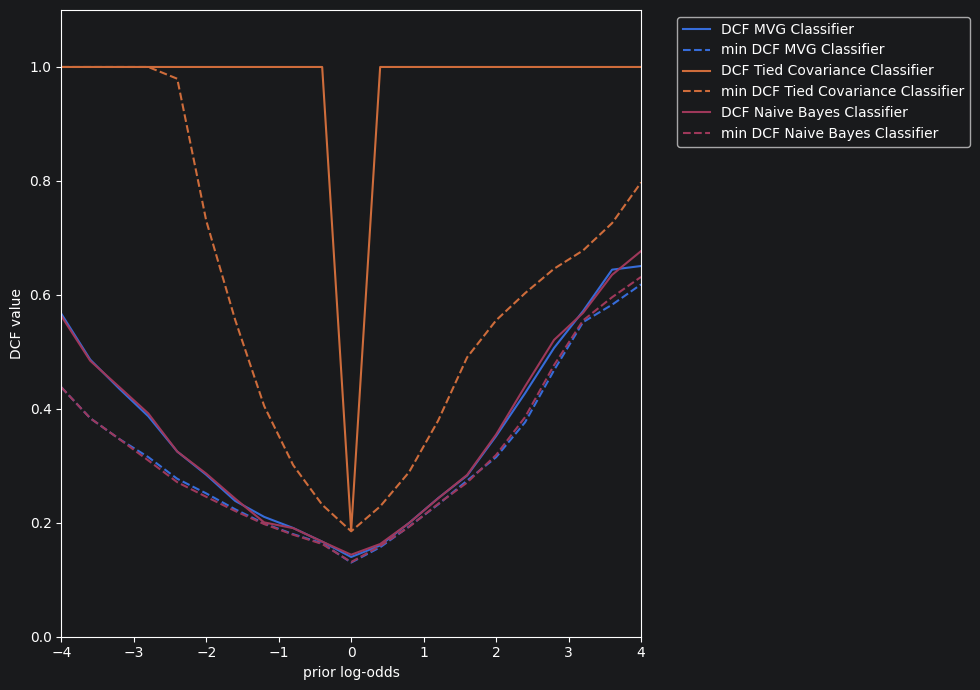

In [8]:
models = {
    "MVG Classifier": llr_MVG,
    "Tied Covariance Classifier": llr_TiedC,
    "Naive Bayes Classifier": llr_Naive,
}

plot_bayes_error(models, LVAL)